Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Introdução ao Python para processamento numérico e análise de dados

# Implementação da rede MLP com PyTorch

Segue a implementação comentada em PyTorch da MLP para solução do problemas das meias luas.

## 1. Treinamento sem a etapa de validação

Iniciando com a importação das bibliotecas:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
# Fixando seeds para poder reproduzir os resultados
np.random.seed(111)
torch.manual_seed(111)
torch.cuda.manual_seed(111)

Definindo a função para gerar dados para treinamento:

In [3]:
# Função para garar dados de treinamento
def meias_luas(NA, NB, r1, r2, r3):
    """
    dados = meias_luas(NA,NB,r1,r2,r3)
    NA: número de pontos da região A
    NB: número de pontos da região B
    r1, r2 e r3: dados das meias-luas
    """

    # total de dados de treinamento
    Nt = NA + NB

    # dados das meia luas
    rmin = r1 - r3 / 2
    rmax = r1 + r3 / 2

    # Pontos da Região A
    a = np.pi * np.random.rand(NA, 1)
    rxy = np.random.uniform(rmin, rmax, (NA, 1))
    x1A = rxy * np.cos(a)
    x2A = rxy * np.sin(a)
    dA = np.ones((NA, 1))
    pontosA = np.hstack((x1A, x2A, dA))

    # Pontos da Região B
    a = np.pi * np.random.rand(NB, 1)
    rxy = np.random.uniform(rmin, rmax, (NB, 1))
    x1B = rxy * np.cos(a) + r1
    x2B = -rxy * np.sin(a) - r2
    dB = -np.ones((NB, 1))    
    pontosB = np.hstack((x1B, x2B, dB))

    # Concatenando e embaralhando os dados
    dados = np.vstack((pontosA, pontosB))
    np.random.shuffle(dados)

    # Figura para mostrar os dados de treino
    fig, ax1 = plt.subplots()
    ax1.plot(x1A, x2A, ".b")
    ax1.plot(x1B, x2B, ".r")
    plt.xlabel("x_1")
    plt.ylabel("x_2")
    plt.grid(axis="x", color="0.5")
    plt.grid(axis="y", color="0.5")

    return dados

Em seguida, criando os dados para treinamento do modelo:

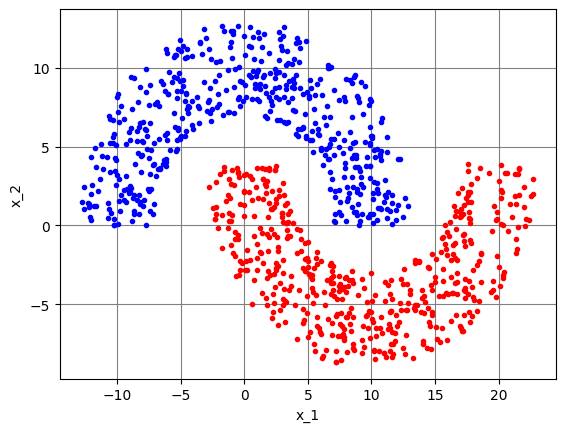

In [4]:
# Gerando dados de treinamento
# Note o uso do sufixo `_np` para facilitar a identificação
# de arrays do NumPy e não confundi-los com tensores do PyTorch

# número de pontos de treinamento da Região A
NA = 500

# número de pontos de treinamento da Região B
NB = 500

# número total de dados de treinamento
Nt = NA + NB

r1 = 10
r3 = 6
r2 = -4

dados_treino_np = meias_luas(NA, NB, r1, r2, r3)

Ajustando os valores dos hiperparâmetros:

In [5]:
# Ajuste de hiperparâmetros

# passo de adaptação da rede MLP
eta = 0.5

# Tamanho do mini-batch
Nb = 100

# Número de épocas
Ne = 10000

O PyTorch utiliza um elemento chamado de `DataLoader` para facilitar o carregamento dos dados, embaralhamento e geração dos mini *batches*. Ele é criado a partir de um iterador, que contém pares de dados no formato `(entrada, saída)`:

In [6]:
dados_treino = torch.tensor(dados_treino_np, dtype=torch.float32)
train_set = [
    (dados_treino[i, [0, 1]], dados_treino[i, [2]])
    for i in range(dados_treino.shape[0])
]

train_loader = torch.utils.data.DataLoader(train_set, batch_size=Nb, shuffle=True)

Vale notar alguns detalhes do código anterior:

 - Os dados de treinamento são armazenados em um tensor chamado `dados_treino`, criado a partir do *array* NumPy chamado `dados_treino_np`. Por padrão, o PyTorch trabalha com precisão de 32 bits e o NumPy, com precisão de 64 bits. Dessa forma, pensando em trabalhar na precisão numérica padrão do PyTorch, é necessário especificar `dtype=torch.float32` para criar um tensor com precisão de 32 bits a partir de um *array* com precisão de 64 bits;
 - Nesse exemplo, o iterador usado para criar o `DataLoader` é chamado de `train_set`;
 - Ao criar o DataLoader, é fornecido o tamanho do mini *batch* por meio do argumento `batch_size` e, nesse caso, o `DataLoader` será responsável por embaralhar os dados a cada época, de acordo com o argumento `shuffle`, configurado como `True`;
 - Com essa implementação, o `DataLoader` fornece dois tensores a cada iteração:

In [7]:
example_loader = torch.utils.data.DataLoader(train_set, batch_size=Nb, shuffle=True)

In [8]:
X, d = next(iter(example_loader))

In [9]:
X.shape

torch.Size([100, 2])

In [10]:
d.shape

torch.Size([100, 1])

Note que o número de linhas dos tensores corresponde ao número de elementos do mini *batch*. Por padrão, os modelos do PyTorch esperam tensores de entrada neste formato.

O modelo é definido por meio de uma classe que herda de `nn.Module`:

In [11]:
class Model(nn.Module):

    # Geralmente, os blocos da rede são definidos no método __init__()
    def __init__(self):
        # Necessário chamar __init__() da classe mãe
        super().__init__()
        
        # Uma das formas de se definir um modelo é a sequencial
        self.model = nn.Sequential(
            # Entrada com 2 elementos, conectada a 3 neurônios
            nn.Linear(2, 3),
            # Função de ativação Tanh
            nn.Tanh(),
            
            # Saídas de 3 neurônios conectadas a 5 neurônios
            nn.Linear(3, 5),
            nn.Tanh(),
            
            nn.Linear(5, 5),
            nn.Tanh(),
            
            nn.Linear(5, 2),
            nn.Tanh(),
            
            nn.Linear(2, 1),
            nn.Tanh(),            
        )

    # O método forward() define como é feito o cálculo progressivo
    # para obter a saída da rede, a partir da entrada x.
    # Nesse caso, como foi definido um modelo sequencial em
    # self.model, basta chamar self.model(x)
    def forward(self, x):
        output = self.model(x)
        return output

Uma das vantagens de se usar o PyTorch para desenvolver aplicações de aprendizado de máquina é a possibilidade do uso de GPUs para acelerar o processo computação de forma simples

Geralmente é criado um objeto chamado `device` que aponta para a GPU, caso ela exista ou para a CPU, caso contrário, como mostrado a seguir:

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")    

Com esse objeto criado, basta chamar o método `.to(device=device)` de tensores ou modelos, para enviá-los à GPU, caso ela exista.

Tendo a classe do modelo definida, é necessário instanciar um objeto para representá-lo. Na linha a seguir, o modelo é instanciado e enviado à GPU com o método `.to()`, caso ela exista:

In [13]:
model = Model().to(device=device)

Definindo a função custo e o otimizador:

In [14]:
loss_function = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=eta)

Nesse caso, utiliza-se a função custo do erro quadrático médio `MSELoss` e o otimizador baseado no gradiente descendente estocástico `SGD`. O PyTorch conta com uma série de outras fuções custo e otimizadores que podem ser utilizados. Para referência, consulte:

 - Funções custo: [https://pytorch.org/docs/stable/nn.html#loss-functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
 - Otimizadores: [https://pytorch.org/docs/stable/optim.html#algorithms](https://pytorch.org/docs/stable/optim.html#algorithms)

Um diferencial do PyTorch é que o treinamento deve ser feito explicitamente, com um *loop* para as épocas e outro para os mini batches:

Época: 0 Loss: 0.5397309064865112
Época: 500 Loss: 4.2221665353281423e-05
Época: 1000 Loss: 9.045926162798423e-06
Época: 1500 Loss: 5.263632374408189e-06
Época: 2000 Loss: 3.6803758121095598e-06
Época: 2500 Loss: 2.8507993192761205e-06
Época: 3000 Loss: 2.273268592034583e-06
Época: 3500 Loss: 1.953314040292753e-06
Época: 4000 Loss: 1.7074105471692747e-06
Época: 4500 Loss: 1.4421326568481163e-06
Época: 5000 Loss: 1.320619730904582e-06
Época: 5500 Loss: 1.2237804867254454e-06
Época: 6000 Loss: 1.0987090490743867e-06
Época: 6500 Loss: 1.0110974244526005e-06
Época: 7000 Loss: 9.265424409932166e-07
Época: 7500 Loss: 8.716854722479184e-07
Época: 8000 Loss: 7.869209639466135e-07
Época: 8500 Loss: 8.086310003818653e-07
Época: 9000 Loss: 7.067936280691356e-07
Época: 9500 Loss: 6.752062517989543e-07


Text(0, 0.5, 'Loss')

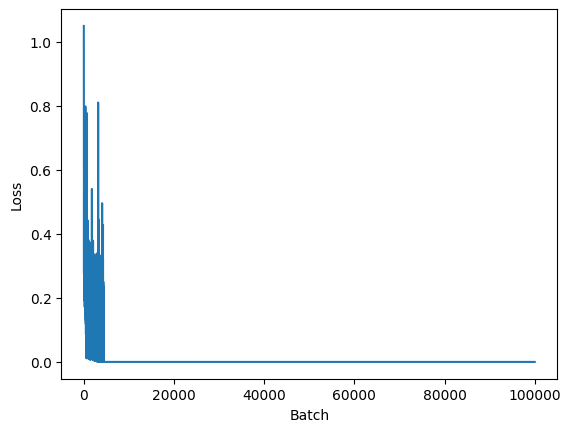

In [15]:
# Lista usada para guardar o valor da função custo ao longo das iterações
losses = []

# Loop das épocas
for epoch in range(Ne):
    # Loop dos mini batches - note que é usado o DataLoader para obter
    # os sinais de entrada e desejado, X e d
    for n, (X, d) in enumerate(train_loader):

        # Envia os dados para a GPU, caso ela exista
        X = X.to(device=device)
        d = d.to(device=device)
        
        # Coloca o modelo em modo treinamento. Isso não é necessário nesse
        # caso, pois não estamos fazendo validação. Mas é interessante manter
        # a linha para lembrar desse detalhe
        model.train()

        # Zera informações de gradientes: por padrão o PyTorch acumula os 
        # gradientes a cada chamada de loss.backward(). Na maioria dos casos,
        # estamos interessados apenas no último valor dos gradientes
        model.zero_grad()
        
        # Calcula a saída
        y = model(X)

        # Calcula o valor da função custo
        loss = loss_function(y, d)
        
        # Calcula os gradientes
        loss.backward()
        
        # Atualiza os pesos do modelo, de acordo com as regras
        # do otimizador escolhido
        optimizer.step()
        
        # Armazena o valor da função custo
        losses.append(loss.item())
        
        # Mostra o valor da função custo a cada 500 épocas        
        if epoch % 500 == 0 and n == dados_treino.shape[0]//Nb - 1:
            print(f"Época: {epoch} Loss: {loss}")

plt.figure()
plt.plot(losses)
plt.xlabel("Batch")
plt.ylabel("Loss")

Para testar o modelo, geramos dados de teste:

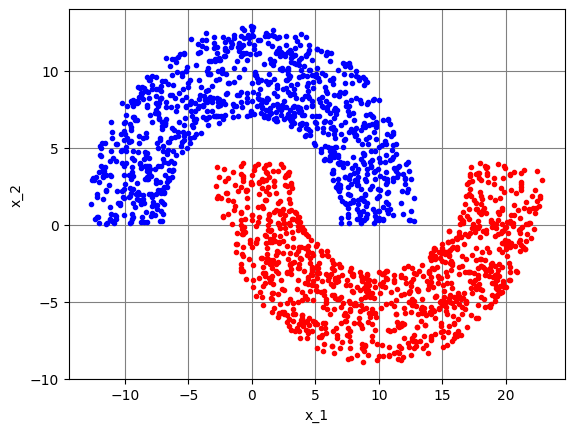

In [16]:
# Dados de teste
NAt = 1000
NBt = 1000
Nteste = NAt + NBt

dados_teste = meias_luas(NAt, NBt, r1, r2, r3)

Convertemos os arrays do NumPy para tensores do PyTorch e enviamos os dados para a GPU, caso ela exista:

In [17]:
xteste = torch.tensor(dados_teste[:,[0,1]], dtype=torch.float32).to(device=device)
dteste = torch.tensor(dados_teste[:,[2]], dtype=torch.float32).to(device=device)

Calculamos a saída do modelo considerando os dados de teste como entrada e convertemos a saída para um *array* do NumPy:

In [18]:
yteste = model(xteste)
yteste_np = yteste.cpu().detach().numpy()

Note que, para obter o *array* do NumPy, é necessário:

 - Chamar o método `.cpu()` para trazer de volta os dados da GPU, caso ela exista;
 - Chamar o método `.detach()` para tirar o tensor do grafo computacional. Isso é necessário para que não sejam calculados os gradientes referentes às operações que eventualmente sejam feitas com `yteste`. Na prática, quase sempre que seja necessário converter um tensor PyTorch para um *array* NumPy, será necessário chamar o método .detach() antes;
 - Chamar o método `.numpy()` para converter os dados para um *array* do NumPy.

Também é possível plotar a fronteira de separação, de forma semelhante à utilizada anteriormente. A diferença é a necessidade da conversão dos dados para tensores do PyTorch para utilizar o modelo e a conversão de volta para *arrays* do NumPy para plotar o gráfico com o Matplotlib:

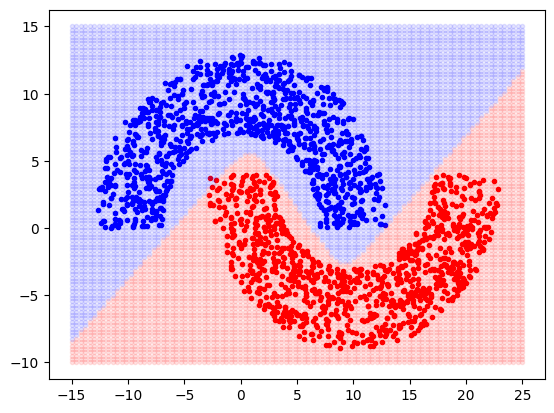

In [19]:
# Gera a curva de separação das duas regiões
# Dados da curva de separação
Nsep = 100
x1S = np.linspace(-15, 25, Nsep).reshape(-1, 1)
x2S = np.linspace(-10, 15, Nsep).reshape(-1, 1)

# Gera pontos da grade
xx1S, xx2S = np.meshgrid(x1S, x2S)
xx1S = xx1S.reshape(-1, 1)
xx2S = xx2S.reshape(-1, 1)

# Gera array x
Ngrid = len(xx1S)
xgrid_np = np.hstack((xx1S, xx2S))

# Calcula saída para cada ponto da grade
xgrid = torch.tensor(xgrid_np, dtype=torch.float32).to(device=device)
ygrid = model(xgrid)
ygrid_dec = torch.sign(ygrid)

ygrid_np = ygrid.cpu().detach().numpy()
ygrid_dec_np = ygrid_dec.cpu().detach().numpy()

xteste_np = xteste.cpu().detach().numpy()
dteste_np = dteste.cpu().detach().numpy()

# Plota os pontos principais
fig, ax2 = plt.subplots()
for i in range(Nteste):
    if dteste_np[i] == 1:
        ax2.plot(xteste_np[i, 0], xteste_np[i, 1], ".b")
    else:
        ax2.plot(xteste_np[i, 0], xteste_np[i, 1], ".r")

# Plota pontos da grade com saída 0 (usa transparência alpha)        
l0 = np.where(ygrid_dec_np == -1)[0]
ax2.plot(xgrid_np[l0, 0], xgrid_np[l0, 1], "r.", alpha=0.1)

# Plota pontos da grade com saída 1 (usa transparência alpha)
l1 = np.where(ygrid_dec_np == 1)[0]
ax2.plot(xgrid_np[l1, 0], xgrid_np[l1, 1], "b.", alpha=0.1)

Calculando a taxa de erros:

In [20]:
yteste_np_dec = np.sign(yteste_np)

Taxa_de_erro = np.sum(np.absolute(dteste_np - yteste_np_dec)) * 100 / (2 * Nteste)

print(f"Taxa de erro: {Taxa_de_erro}")

Taxa de erro: 0.05000000074505806


## 2. Validação cruzada *hold-out*

É interessante usar um conjunto de dados de validação durante o treinamento para observar se não está ocorrendo *overfitting* do modelo:

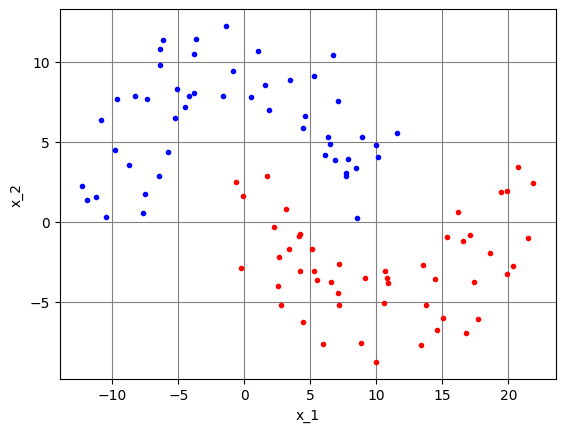

In [21]:
NAv = 50
NBv = 50
dados_val = meias_luas(NAv, NBv, r1, r2, r3)

X_val = torch.tensor(dados_val[:,[0,1]], dtype=torch.float32).to(device=device)
d_val = torch.tensor(dados_val[:,[2]], dtype=torch.float32).to(device=device)

Segue um exemplo da rotina de treinamento considerando a etapa de validação. As diferenças em relação à rotina mostrado anteriormente estão destacadas. Vale notar alguns detalhes:

 - A necessidade de colocar o modelo em modo treinamento (train) para atualizar os pesos e inferência (eval) para calcular o valor da função custo de validação;
 - Para o cálculo da saída e do valor da função custo, não é necessário calcular gradientes.

Epoch: 0 Loss: 0.5027859210968018 Val. Loss: 0.4702392518520355
Epoch: 500 Loss: 0.014364180155098438 Val. Loss: 0.00017858465434983373
Epoch: 1000 Loss: 9.866827895166352e-06 Val. Loss: 9.640273674449418e-06
Epoch: 1500 Loss: 5.4211923270486295e-06 Val. Loss: 5.332761247700546e-06
Epoch: 2000 Loss: 3.7570675885945093e-06 Val. Loss: 3.6991368688177317e-06
Epoch: 2500 Loss: 2.902035930674174e-06 Val. Loss: 2.8353019843052607e-06
Epoch: 3000 Loss: 2.484635842847638e-06 Val. Loss: 2.299876314282301e-06
Epoch: 3500 Loss: 1.918974021464237e-06 Val. Loss: 1.9352103208802873e-06
Epoch: 4000 Loss: 1.6821684312162688e-06 Val. Loss: 1.670778601692291e-06
Epoch: 4500 Loss: 1.5319814110625884e-06 Val. Loss: 1.4700692645419622e-06
Epoch: 5000 Loss: 1.2996845271118218e-06 Val. Loss: 1.312647668783029e-06
Epoch: 5500 Loss: 1.260786916645884e-06 Val. Loss: 1.1858140851472854e-06
Epoch: 6000 Loss: 1.1408079672037275e-06 Val. Loss: 1.081413188330771e-06
Epoch: 6500 Loss: 1.0122498679265846e-06 Val. Loss

Text(0, 0.5, 'Loss')

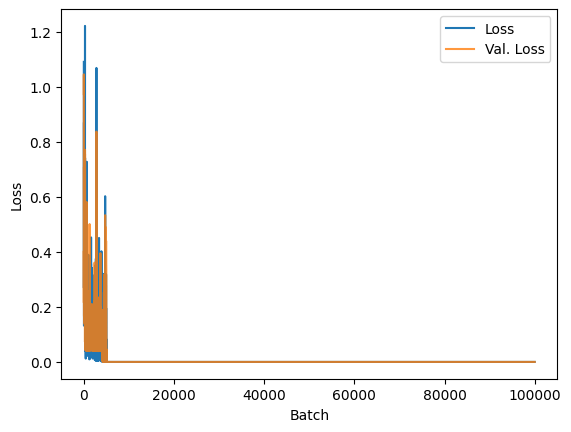

In [22]:
# Reiniciando o modelo e otimizador
model = Model().to(device=device)
optimizer = torch.optim.SGD(model.parameters(), lr=eta)

# Listas para guardar o valor da função custo
# no treinamento e validação ao longo das iterações
losses = []
val_losses = []

for epoch in range(Ne):
    for n, (X, d) in enumerate(train_loader):
        X = X.to(device=device)
        d = d.to(device=device)
        
        # Necessário colocar o modelo em modo treinamento
        # na etapa de treinamento
        model.train()
        model.zero_grad()
        y = model(X)
        loss = loss_function(y, d)
        loss.backward()
        optimizer.step()

        # Validação
        # Necessário colocar o modelo em modo de inferência (eval)
        # pois algumas camadas têm comportamento diferente para inferência,
        # por exemplo, o Dropout.
        model.eval()

        # Cálculo da saída e valor da função custo com os dados de validação
        # Nesse caso, não é necessário calcular gradientes, por isso é utilizado
        # o bloco with torch.no_grad():
        with torch.no_grad():
            y_val = model(X_val)
            val_loss = loss_function(y_val, d_val)

        # Armazena o valor da função custo de treinamento e validação
        losses.append(loss.item())
        val_losses.append(val_loss.item())
        
        # Mostra os valores da função custo de treinamento e validação
        # a cada 500 épocas        
        if epoch % 500 == 0 and n == dados_treino.shape[0]//Nb - 1:
            print(f"Epoch: {epoch} Loss: {loss} Val. Loss: {val_loss}")

plt.figure()
plt.plot(losses)
plt.plot(val_losses, alpha=0.8)
plt.legend(["Loss", "Val. Loss"])
plt.xlabel("Batch")
plt.ylabel("Loss")

## 3. Utilizando outras funções de ativação

O PyTorch disponibiliza uma lista grande de funções de ativação que podem ser utilizadas. Para referência, acesse [https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity).

Para usar ReLU, por exemplo, utiliza-se a função `nn.ReLU`:

In [23]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()        
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 5),
            nn.ReLU(),
            nn.Linear(5, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

Outra função muito usada é a sigmoide, nos casos em que é necessário limitar uma saída entre 0 e 1. A implementação é feita com `nn.Sigmoid()`:

In [24]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()        
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.Sigmoid(),
            nn.Linear(3, 5),
            nn.Sigmoid(),
            nn.Linear(5, 2),
            nn.Sigmoid(),
            nn.Linear(2, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

## 4. Utilizando *dropout*

Para utilizar *Dropout*, basta adicionar camadas do tipo `nn.Dropout(n)`, em que `n` representa a proporção de neurônios que deve ser desativada. No exemplo a seguir é utilizado *Dropout* de 10% para os neurônios da primeira camada:

In [25]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()        
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(3, 5),
            nn.Tanh(),
            nn.Linear(5, 2),
            nn.Tanh(),
            nn.Linear(2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

## 5. Utilizando o otimizador Adam

Para utilizar o Adam, basta criar o otimizador usando [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam):

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=eta, betas=(0.9, 0.999))

## 6. Utilizando a função custo da entropia cruzada

A função custo da entropia cruzada binária é implementada pela classe [`torch.nn.BCELoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html). Para utilizá-la, basta definir:

In [27]:
loss_function = nn.BCELoss()

No caso de classificação multiclasse, pode-se utilizar a classe [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Vale notar que essa função custo espera comparar um vetor de $C$ posições com um número de $0$ a $C-1$. Além disso, é esperado que os elementos do vetor representem a evidência, ou seja os valores chamados de *logits*, que não são normalizados e podem valer de $-\infty$ a $\infty$. Por isso, na saída da rede, não deve ser usada a função Softmax.

## 7. Inicialização de pesos

Uma forma de inicializar os pesos da rede é definir uma função para inicializar os parâmetros de um elemento do modelo e usar o método `.apply()` para aplicar essa função à todos os elementos do modelo:

In [28]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()        
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.Tanh(),
            nn.Linear(3, 5),
            nn.Tanh(),
            nn.Linear(5, 2),
            nn.Tanh(),
            nn.Linear(2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        return output

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")    

model = Model().to(device=device)    
    
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        torch.nn.init.xavier_normal_(m.weight)
        torch.nn.init.zeros_(m.bias)

model.apply(weights_init)


Model(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=5, bias=True)
    (3): Tanh()
    (4): Linear(in_features=5, out_features=2, bias=True)
    (5): Tanh()
    (6): Linear(in_features=2, out_features=1, bias=True)
    (7): Tanh()
  )
)

Nesse exemplo, é usada a inicialização de Xavier, com distribuição Gaussiana (`torch.nn.init.xavier_normal_`). Além dela, há diversas outras alternativas, listadas em [https://pytorch.org/docs/stable/nn.init.html](https://pytorch.org/docs/stable/nn.init.html).

## 8. Utilizando passo de adaptação variável (*annealing*)

O Pytorch oferece algumas classes que permitem o uso de passo variável de acordo com diferentes regras. Essas classes são agupadas em `torch.optim.lr_scheduler`. Seguem alguns exemplos:

- [`torch.optim.lr_scheduler.StepLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html)
- [`torch.optim.lr_scheduler.ExponentialLR`](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html)

Para implementar, é necessário criar um objeto que controla o ajuste do passo variável, geralmente chamado de `scheduler`, indicando o otimizador escolhido. Além disso, no loop de treinamento, deve-se chamar o método `.step()` do objeto `scheduler`, após chamar o do otimizador. Segue um exemplo:

``` python
# (...)

optimizer = torch.optim.SGD(model.parameters(), lr=eta)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

losses = []

# Loop das épocas

for epoch in range(Ne):
    for n, (X, d) in enumerate(train_loader):

        X = X.to(device=device)
        d = d.to(device=device)
        
        model.train()
        model.zero_grad()
        y = model(X)
        loss = loss_function(y, d)
        loss.backward()
       
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        if epoch % 500 == 0 and n == dados_treino.shape[0]//Nb - 1:
            print(f"Época: {epoch} Loss: {loss}")

```

## 9. Utilizando normalização em lote (*batch normalization*)

O Pytorch disponibiliza a classe [`BatchNorm1d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html) para implementar uma camada de normalização em lote em redes MLP. Geralmente as camadas de normalização em lote são inseridas depois de uma camada `Linear` e antes da função de ativação. Quando utilizada a normalização em lote, é uma prática comum desabilitar o *bias* da camada `Linear` anterior tendo em vista que a camada de normalização em lote adapta um parâmetro que funciona como `bias`.

Segue um exemplo:

```python

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(2, 3, bias=False),
            nn.BatchNorm1d(3),
            nn.Tanh(),
            
            nn.Linear(3, 5, bias=False),
            nn.BatchNorm1d(5),
            nn.Tanh(),
            
            nn.Linear(5, 5, bias=False),
            nn.BatchNorm1d(5),
            nn.Tanh(),
            
            nn.Linear(5, 2, bias=False),
            nn.BatchNorm1d(2),
            nn.Tanh(),
            
            nn.Linear(2, 1),            
            nn.Tanh(),            
        )
```